# LSTM behavior analysis (XAI) — agent-final

Run **after** `train_hourly.ipynb` and/or `train_15min.ipynb` (models must exist on Drive).

This notebook:
1. Computes **SHAP** and **LIME** feature importance (+ Spearman agreement)
2. Computes **Integrated Gradients (IG)** memory horizon
3. Runs **behavior tests** (memory erasure, fidelity)
4. Overlays IG curves across architectures and plots **hidden states** for the best model

**Clean data:** 9 features (no CO2 / NSM / leading reactive leakage).

Outputs → `outputs/behaviors/{hourly,15min}/`

Set `FORCE_RECOMPUTE = True` only if you want to redo everything.

In [1]:
FORCE_RECOMPUTE = False
# Recompute ONLY LIME + Spearman (leave SHAP/IG/erasure/fidelity untouched)
FORCE_RECOMPUTE_LIME = True
test_ratio = 0.18

TRACKS = ["hourly", "15min"]
STACKS = ["single", "double", "bidir"]
WINDOWS = {
    "hourly": [1, 4, 8, 12, 16, 24, 36, 48, 74, 168, 336, 672],
    "15min": [1, 4, 8, 16, 24, 48, 64, 96, 672],
}

# quick test: WINDOWS = {"hourly": [8, 24], "15min": [8, 24]}

COMPARE_WINDOW = 24
ERASE_CUTOFFS = [0.0, 0.25, 0.5, 0.75]
IG_SAMPLES = 20
LIME_TEST = 10
LIME_SAMPLES = 200
FIDELITY_TOP_K = 2

## Setup (Colab)

In [2]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow shap lime scipy

from google.colab import drive
drive.mount("/content/drive")
BASE = "/content/drive/MyDrive/Shared-Colab-Storage/agent-final"

print("BASE:", BASE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/Shared-Colab-Storage/agent-final


In [3]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model


def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_true - y_pred)))


def build_windows(scaled_df, feature_cols, window, test_ratio=0.18):
    arr = scaled_df[feature_cols].to_numpy(dtype=np.float32)
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i + window])
        y.append(arr[i + window, 0])
    X, y = np.array(X), np.array(y)
    split = int(len(X) * (1 - test_ratio))
    return X[:split], X[split:], y[:split], y[split:]


def to_kwh(vals, scaler, n_features, target_idx=0):
    vals = np.asarray(vals).ravel()
    d = np.zeros((len(vals), n_features))
    d[:, target_idx] = vals
    return scaler.inverse_transform(d)[:, target_idx]


def integrated_gradients(model, x, baseline, steps=50):
    x_t = tf.convert_to_tensor(x[np.newaxis, ...], dtype=tf.float32)
    b_t = tf.convert_to_tensor(baseline[np.newaxis, ...], dtype=tf.float32)
    grads_sum = tf.zeros_like(x_t)
    for alpha in tf.linspace(0.0, 1.0, steps + 1):
        with tf.GradientTape() as tape:
            interp = b_t + alpha * (x_t - b_t)
            tape.watch(interp)
            pred = model(interp, training=False)
        grads_sum += tape.gradient(pred, interp)
    return ((x_t - b_t) * (grads_sum / float(steps + 1))).numpy()[0]


def track_paths(track):
    preprocess = os.path.join(BASE, "outputs", "preprocess", track)
    train = os.path.join(BASE, "outputs", "train", track)
    behaviors = os.path.join(BASE, "outputs", "behaviors", track)
    return {
        "preprocess": preprocess,
        "train": train,
        "behaviors": behaviors,
        "data_csv": os.path.join(preprocess, "data.csv"),
        "scaler_pkl": os.path.join(preprocess, "scaler.pkl"),
        "metrics_csv": os.path.join(train, "results_metrics.csv"),
    }


def model_path(train_root, stack, window):
    return os.path.join(train_root, stack, "models", f"win{window}.keras")

## Load preprocessed data

We reuse `data.csv` and `scaler.pkl` from preprocess, and trained models from `outputs/train/`.

In [4]:
track_data = {}

for track in TRACKS:
    paths = track_paths(track)
    if not os.path.exists(paths["data_csv"]):
        print(f"Skip {track}: run preprocess.ipynb first")
        continue
    scaled_df = pd.read_csv(paths["data_csv"])
    with open(paths["scaler_pkl"], "rb") as f:
        scaler = pickle.load(f)
    feature_cols = list(scaled_df.columns)
    os.makedirs(paths["behaviors"], exist_ok=True)
    track_data[track] = {
        "paths": paths,
        "scaled_df": scaled_df,
        "scaler": scaler,
        "feature_cols": feature_cols,
    }
    print(track, "loaded:", scaled_df.shape, "features:", feature_cols)

hourly loaded: (8760, 9) features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_sin', 'hour_cos']
15min loaded: (35040, 9) features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_sin', 'hour_cos']


---
# Part 1 — SHAP (feature importance)

**Question:** Which input features matter most for the prediction?

**Method:** SHAP measures how much each feature changes the output.

**How to read:** Higher bar = model relies more on that feature. With clean data we expect `Usage_kWh` (past energy) to rank high — not CO2.

Runs for every saved model (single / double / bidir × all window sizes).

In [7]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    out_root = os.path.join(paths["behaviors"], "shap")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            if not os.path.exists(mpath):
                continue

            os.makedirs(os.path.join(out_root, stack), exist_ok=True)
            shap_csv = os.path.join(out_root, stack, f"win{window}.csv")
            shap_png = os.path.join(out_root, stack, f"win{window}.png")
            if os.path.exists(shap_csv) and os.path.exists(shap_png) and not FORCE_RECOMPUTE:
                print(f"exists: {track} {stack} win{window} shap")
                continue

            print(f"SHAP {track} {stack} win{window}...")
            model = load_model(mpath, custom_objects={"rmse": rmse})
            X_train, X_test, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
            w, nf = window, X_train.shape[2]

            bg = X_train[:50].reshape(50, w * nf)
            test_flat = X_test[:15].reshape(15, w * nf)
            explainer = shap.KernelExplainer(
                lambda x: model.predict(x.reshape(-1, w, nf), verbose=0).ravel(), bg)
            sv = explainer.shap_values(test_flat, nsamples=40)
            labels = [f"t-{w - 1 - t}_{feature_cols[f]}" for t in range(w) for f in range(nf)]
            shap_df = pd.DataFrame({"feature": labels, "val": np.abs(sv).mean(0)})
            shap_df["attr"] = shap_df["feature"].str.replace(r"^t-\d+_", "", regex=True)
            rank = shap_df.groupby("attr")["val"].sum().sort_values(ascending=False).reset_index()
            rank.columns = ["attr", "value"]
            rank.to_csv(shap_csv, index=False)

            top = rank.head(8)
            plt.figure(figsize=(7, 4))
            plt.barh(top["attr"], top["value"])
            plt.gca().invert_yaxis()
            plt.xlabel("SHAP importance")
            plt.title(f"{track} {stack} win{window}")
            plt.tight_layout()
            plt.savefig(shap_png, dpi=120)
            plt.close()

SHAP hourly single win1...


  0%|          | 0/15 [00:00<?, ?it/s]

SHAP hourly single win4...


  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=6.720e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=4.293e-03, with an active set of 3 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


...

  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=1.023e-01, with an active set of 2 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=3.262e-02, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up

SHAP 15min bidir win672...


  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=1.188e+00, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 

---
# Part 2 — LIME + SHAP agreement (Spearman)

**Question:** Do two different explainers agree on which features matter?

**Method:** LIME perturbs inputs locally; we rank features by mean |weight|. Then compare that ranking to Part 1 SHAP using **Spearman correlation** (1 = perfect agreement, 0 = unrelated).

**How to read:** High Spearman → both methods point at the same drivers. Low or negative → treat feature rankings cautiously.

Needs SHAP CSV from Part 1. Runs for every saved model.

In [8]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    lime_root = os.path.join(paths["behaviors"], "lime")
    corr_root = os.path.join(paths["behaviors"], "shap_lime")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            shap_csv = os.path.join(paths["behaviors"], "shap", stack, f"win{window}.csv")
            if not os.path.exists(mpath) or not os.path.exists(shap_csv):
                continue

            os.makedirs(os.path.join(lime_root, stack), exist_ok=True)
            os.makedirs(os.path.join(corr_root, stack), exist_ok=True)
            lime_csv = os.path.join(lime_root, stack, f"win{window}.csv")
            corr_csv = os.path.join(corr_root, stack, f"win{window}.csv")
            recompute = FORCE_RECOMPUTE or FORCE_RECOMPUTE_LIME
            if os.path.exists(lime_csv) and os.path.exists(corr_csv) and not recompute:
                print(f"exists: {track} {stack} win{window} lime")
                continue

            print(f"LIME {track} {stack} win{window}...")
            model = load_model(mpath, custom_objects={"rmse": rmse})
            X_train, X_test, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
            w, nf = window, X_train.shape[2]

            if not os.path.exists(lime_csv) or recompute:
                train_flat = X_train.reshape(len(X_train), w * nf)
                test_n = min(LIME_TEST, len(X_test))
                test_flat = X_test[:test_n].reshape(test_n, w * nf)
                lime_exp = LimeTabularExplainer(train_flat, mode="regression", verbose=False)
                importance = np.zeros(nf)
                for i in range(test_n):
                    exp = lime_exp.explain_instance(
                        test_flat[i],
                        lambda x: model.predict(x.reshape(-1, w, nf), verbose=0).ravel(),
                        num_samples=LIME_SAMPLES,
                        num_features=w * nf,
                    )
                    # exp.as_map() returns {class: [(flat_col_idx, weight), ...]}.
                    # The flattened layout is (timestep, feature), so the base
                    # feature for column idx is idx % nf. (Old code matched names
                    # in as_list() strings, which never matched -> all zeros.)
                    m = exp.as_map()
                    pairs = m.get(1) or m.get(0) or next(iter(m.values()))
                    for idx, wt in pairs:
                        importance[idx % nf] += abs(wt)
                lime_df = pd.DataFrame({"attr": feature_cols, "value": importance / max(test_n, 1)})
                lime_df = lime_df.sort_values("value", ascending=False)
                lime_df.to_csv(lime_csv, index=False)

            shap_rank = pd.read_csv(shap_csv).set_index("attr")
            lime_rank = pd.read_csv(lime_csv).set_index("attr")
            merged = shap_rank.join(lime_rank, lsuffix="_shap", rsuffix="_lime", how="inner")
            if len(merged) >= 2:
                corr, p = spearmanr(merged["value_shap"], merged["value_lime"])
            else:
                corr, p = np.nan, np.nan
            pd.DataFrame([{
                "track": track, "model": stack, "window": window,
                "spearman": corr, "p_value": p, "n_attrs": len(merged),
            }]).to_csv(corr_csv, index=False)
            print(f"  Spearman={corr:.3f}" if corr == corr else "  Spearman=nan")

LIME hourly single win1...


/tmp/ipykernel_43705/1204181985.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(merged["value_shap"], merged["value_lime"])


  Spearman=nan
LIME hourly single win4...


/tmp/ipykernel_43705/1204181985.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(merged["value_shap"], merged["value_lime"])


  Spearman=nan
LIME hourly single win8...


...

/tmp/ipykernel_43705/1204181985.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(merged["value_shap"], merged["value_lime"])


  Spearman=nan
LIME 15min bidir win96...


/tmp/ipykernel_43705/1204181985.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(merged["value_shap"], merged["value_lime"])


  Spearman=nan
LIME 15min bidir win672...
  Spearman=nan


/tmp/ipykernel_43705/1204181985.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(merged["value_shap"], merged["value_lime"])


---
# Part 3 — Integrated Gradients (memory horizon)

**Question:** Which **time steps** in the input window does the LSTM use?

**Method:** IG attributes the prediction to each hour (or 15-min step) in the window.

**How to read the line plot:**
- X-axis 0 = **oldest** step in the window, right side = **most recent**
- Y-axis = mean |attribution| (higher = more important)
- **Single/double:** often flat then spike at the end → **recency bias**
- **Bidirectional:** U-shape → uses **start and end**, ignores **middle**

Runs for every saved model.

In [9]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    out_root = os.path.join(paths["behaviors"], "ig")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            if not os.path.exists(mpath):
                continue

            os.makedirs(os.path.join(out_root, stack), exist_ok=True)
            csv_path = os.path.join(out_root, stack, f"win{window}.csv")
            png_path = os.path.join(out_root, stack, f"win{window}.png")
            if os.path.exists(csv_path) and os.path.exists(png_path) and not FORCE_RECOMPUTE:
                print(f"exists: {track} {stack} win{window} ig")
                continue

            print(f"IG {track} {stack} win{window}...")
            model = load_model(mpath, custom_objects={"rmse": rmse})
            X_train, X_test, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
            baseline = X_train.mean(axis=0)

            n = min(IG_SAMPLES, len(X_test))
            curves = []
            for i in range(n):
                attr = integrated_gradients(model, X_test[i], baseline)
                curves.append(np.abs(attr).mean(axis=1))
            horizon = np.mean(curves, axis=0)

            pd.DataFrame({"step": np.arange(window), "mean_abs_attr": horizon}).to_csv(csv_path, index=False)

            plt.figure(figsize=(8, 3))
            plt.plot(np.arange(window), horizon, "o-")
            plt.xlabel("Time step (0=oldest, right=recent)")
            plt.ylabel("Mean |attribution|")
            plt.title(f"{track} {stack} win{window} memory horizon")
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.close()

IG hourly single win1...
IG hourly single win4...
IG hourly single win8...
IG hourly single win12...
IG hourly single win16...
IG hourly single win24...
IG hourly single win36...
IG hourly single win48...
IG hourly single win74...
IG hourly single win168...
IG hourly single win336...
IG hourly single win672...
IG hourly double win1...
IG hourly double win4...
IG hourly double win8...
IG hourly double win12...
IG hourly double win16...
IG hourly double win24...
IG hourly double win36...
IG hourly double win48...
IG hourly double win74...
IG hourly double win168...
IG hourly double win336...
IG hourly double win672...
IG hourly bidir win1...
IG hourly bidir win4...
IG hourly bidir win8...
IG hourly bidir win12...
IG hourly bidir win16...
IG hourly bidir win24...
IG hourly bidir win36...
IG hourly bidir win48...
IG hourly bidir win74...
IG hourly bidir win168...
IG hourly bidir win336...
IG hourly bidir win672...
IG 15min single win1...
IG 15min single win4...
IG 15min single win8...
IG 1

---
# Part 4 — Memory erasure test

**Question:** If we wipe **old** history, does prediction get worse?

**Method:** Replace the oldest 0%, 25%, 50%, 75% of each window with the training mean, then measure RMSE.

**How to read:**
- Flat line at first → old data was not important (matches IG recency bias)
- RMSE jumps early → model needed that history
- Compare **single vs bidir** at same window: bidir may rise earlier if **first** inputs matter

Runs for every saved model.

In [10]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    scaler = info["scaler"]
    feature_cols = info["feature_cols"]
    n_feat = len(feature_cols)
    out_root = os.path.join(paths["behaviors"], "erasure")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            if not os.path.exists(mpath):
                continue

            os.makedirs(os.path.join(out_root, stack), exist_ok=True)
            csv_path = os.path.join(out_root, stack, f"win{window}.csv")
            png_path = os.path.join(out_root, stack, f"win{window}.png")
            if os.path.exists(csv_path) and os.path.exists(png_path) and not FORCE_RECOMPUTE:
                print(f"exists: {track} {stack} win{window} erasure")
                continue

            print(f"Erasure {track} {stack} win{window}...")
            model = load_model(mpath, custom_objects={"rmse": rmse})
            X_train, X_test, _, y_test = build_windows(scaled_df, feature_cols, window, test_ratio)
            mean_window = X_train.mean(axis=0)
            yt = to_kwh(y_test, scaler, n_feat)

            rows = []
            for cutoff in ERASE_CUTOFFS:
                X_mod = X_test.copy()
                cut = int(window * cutoff)
                if cut > 0:
                    X_mod[:, :cut, :] = mean_window[:cut, :]
                yp = to_kwh(model.predict(X_mod, verbose=0).ravel(), scaler, n_feat)
                rmse_k = float(np.sqrt(mean_squared_error(yt, yp)))
                rows.append({"cutoff": cutoff, "rmse_kwh": rmse_k})

            df = pd.DataFrame(rows)
            df.to_csv(csv_path, index=False)

            plt.figure(figsize=(6, 3))
            plt.plot(df["cutoff"], df["rmse_kwh"], "o-")
            plt.xlabel("Fraction of oldest window erased")
            plt.ylabel("RMSE (kWh)")
            plt.title(f"{track} {stack} win{window}")
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.close()

Erasure hourly single win1...
Erasure hourly single win4...
Erasure hourly single win8...
Erasure hourly single win12...
Erasure hourly single win16...
Erasure hourly single win24...
Erasure hourly single win36...
Erasure hourly single win48...
Erasure hourly single win74...
Erasure hourly single win168...
Erasure hourly single win336...
Erasure hourly single win672...
Erasure hourly double win1...
Erasure hourly double win4...
Erasure hourly double win8...
Erasure hourly double win12...
Erasure hourly double win16...
Erasure hourly double win24...
Erasure hourly double win36...
Erasure hourly double win48...
Erasure hourly double win74...
Erasure hourly double win168...
Erasure hourly double win336...
Erasure hourly double win672...
Erasure hourly bidir win1...
Erasure hourly bidir win4...
Erasure hourly bidir win8...
Erasure hourly bidir win12...
Erasure hourly bidir win16...
Erasure hourly bidir win24...
Erasure hourly bidir win36...
Erasure hourly bidir win48...
Erasure hourly bidi

---
# Part 5 — Fidelity test (trust the explanation?)

**Question:** SHAP says feature X is important — if we break X, does error really increase?

**Method:** Take top features from Part 1 SHAP. Set that feature to 0 across the whole window on the test set. Compare RMSE before vs after.

**How to read:**
- Big RMSE increase → SHAP was **faithful**
- Almost no change → feature may be redundant or SHAP was misleading

Runs for every saved model (needs SHAP from Part 1).

In [11]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    scaler = info["scaler"]
    feature_cols = info["feature_cols"]
    n_feat = len(feature_cols)
    out_root = os.path.join(paths["behaviors"], "fidelity")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            shap_csv = os.path.join(paths["behaviors"], "shap", stack, f"win{window}.csv")
            if not os.path.exists(mpath) or not os.path.exists(shap_csv):
                continue

            os.makedirs(os.path.join(out_root, stack), exist_ok=True)
            csv_path = os.path.join(out_root, stack, f"win{window}.csv")
            png_path = os.path.join(out_root, stack, f"win{window}.png")
            if os.path.exists(csv_path) and os.path.exists(png_path) and not FORCE_RECOMPUTE:
                print(f"exists: {track} {stack} win{window} fidelity")
                continue

            print(f"Fidelity {track} {stack} win{window}...")
            top_attrs = pd.read_csv(shap_csv)["attr"].head(FIDELITY_TOP_K).tolist()
            model = load_model(mpath, custom_objects={"rmse": rmse})
            _, X_test, _, y_test = build_windows(scaled_df, feature_cols, window, test_ratio)
            yt = to_kwh(y_test, scaler, n_feat)
            base_rmse = float(np.sqrt(mean_squared_error(
                yt, to_kwh(model.predict(X_test, verbose=0).ravel(), scaler, n_feat))))

            rows = []
            for attr in top_attrs:
                if attr not in feature_cols:
                    continue
                idx = feature_cols.index(attr)
                X_zero = X_test.copy()
                X_zero[:, :, idx] = 0.0
                rmse_zero = float(np.sqrt(mean_squared_error(
                    yt, to_kwh(model.predict(X_zero, verbose=0).ravel(), scaler, n_feat))))
                rows.append({
                    "attr": attr,
                    "baseline_rmse": base_rmse,
                    "rmse_zero": rmse_zero,
                    "delta": rmse_zero - base_rmse,
                })

            if not rows:
                continue
            df = pd.DataFrame(rows)
            df.to_csv(csv_path, index=False)

            plt.figure(figsize=(6, 3))
            x = np.arange(len(df))
            plt.bar(x - 0.15, [base_rmse] * len(df), width=0.3, label="baseline")
            plt.bar(x + 0.15, df["rmse_zero"], width=0.3, label="after zeroing")
            plt.xticks(x, df["attr"], rotation=30, ha="right")
            plt.ylabel("RMSE (kWh)")
            plt.title(f"{track} {stack} win{window} fidelity")
            plt.legend()
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.close()

Fidelity hourly single win1...
Fidelity hourly single win4...
Fidelity hourly single win8...
Fidelity hourly single win12...
Fidelity hourly single win16...
Fidelity hourly single win24...
Fidelity hourly single win36...
Fidelity hourly single win48...
Fidelity hourly single win74...
Fidelity hourly single win168...
Fidelity hourly single win336...
Fidelity hourly single win672...
Fidelity hourly double win1...
Fidelity hourly double win4...
Fidelity hourly double win8...
Fidelity hourly double win12...
Fidelity hourly double win16...
Fidelity hourly double win24...
Fidelity hourly double win36...
Fidelity hourly double win48...
Fidelity hourly double win74...
Fidelity hourly double win168...
Fidelity hourly double win336...
Fidelity hourly double win672...
Fidelity hourly bidir win1...
Fidelity hourly bidir win4...
Fidelity hourly bidir win8...
Fidelity hourly bidir win12...
Fidelity hourly bidir win16...
Fidelity hourly bidir win24...
Fidelity hourly bidir win36...
Fidelity hourly bi

---
# Part 6 — Compare architectures (same window)

**Question:** Do single, double, and bidirectional LSTM **behave differently** at the same window size?

**What to look for (hourly win24 = 24 hours):**
- **Single / double:** IG spikes only at recent steps
- **Bidir:** U-shape — start and end matter, middle flat

This cell overlays IG curves for all three stacks at `COMPARE_WINDOW`.

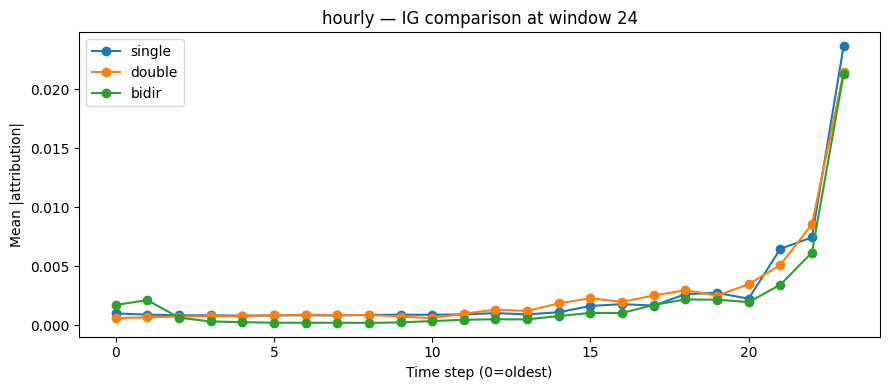

Saved /content/drive/MyDrive/Shared-Colab-Storage/agent-final/outputs/behaviors/hourly/compare_ig_win24.png


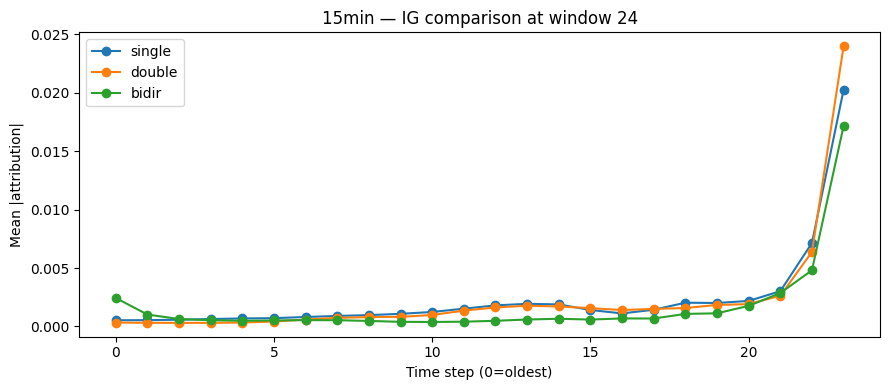

Saved /content/drive/MyDrive/Shared-Colab-Storage/agent-final/outputs/behaviors/15min/compare_ig_win24.png


In [12]:
for track, info in track_data.items():
    paths = info["paths"]
    window = COMPARE_WINDOW
    if window not in WINDOWS[track]:
        print(f"Skip compare for {track}: win{window} not in window list")
        continue

    plt.figure(figsize=(9, 4))
    found = 0
    for stack in STACKS:
        csv_path = os.path.join(paths["behaviors"], "ig", stack, f"win{window}.csv")
        if not os.path.exists(csv_path):
            continue
        d = pd.read_csv(csv_path)
        plt.plot(d["step"], d["mean_abs_attr"], "o-", label=stack)
        found += 1

    if found == 0:
        plt.close()
        print(f"No IG files for {track} win{window} — run Part 3 first")
        continue

    plt.xlabel("Time step (0=oldest)")
    plt.ylabel("Mean |attribution|")
    plt.title(f"{track} — IG comparison at window {window}")
    plt.legend()
    plt.tight_layout()
    out = os.path.join(paths["behaviors"], f"compare_ig_win{window}.png")
    plt.savefig(out, dpi=120)
    plt.show()
    print("Saved", out)

---
# Part 7 — Hidden states (best model only)

**Question:** What does the LSTM's internal memory look like across many inputs?

**Method:** Pass training samples through the first LSTM layer, take the last hidden vector, reduce with PCA. We also save the 2-D coordinates together with **color labels** (`usage_kwh`, `hour`, `load_type`) to `hidden_states_coords.csv` so the scatter can be re-colored later without TensorFlow.

**How to read:** Clusters / smooth gradients in the scatter colored by usage or hour = the model organizes its internal memory by load regime or time of day.

Hidden states hourly: best = single win36


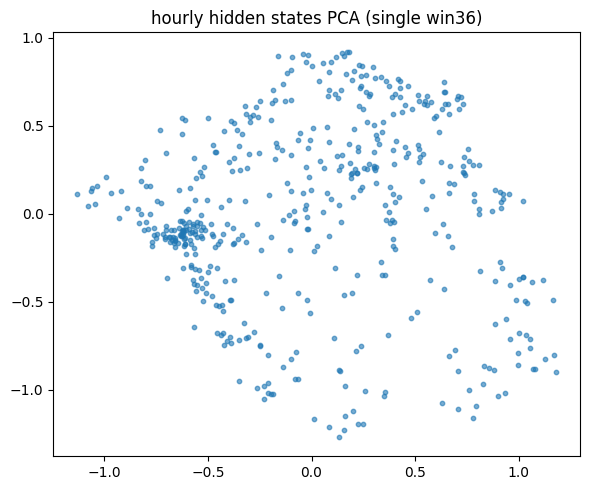

Saved /content/drive/MyDrive/Shared-Colab-Storage/agent-final/outputs/behaviors/hourly/hidden_states_pca.png
Hidden states 15min: best = single win16


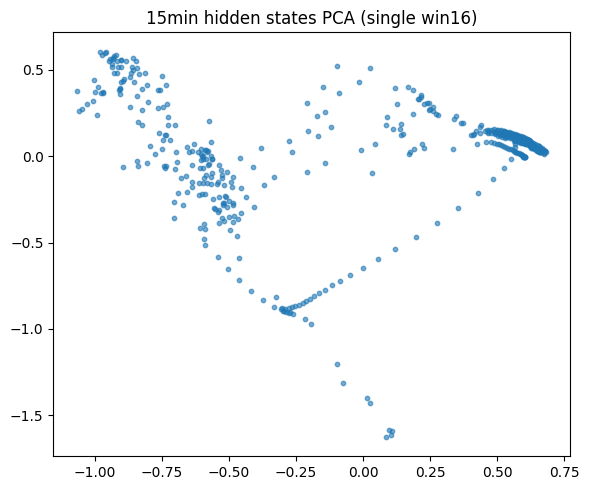

Saved /content/drive/MyDrive/Shared-Colab-Storage/agent-final/outputs/behaviors/15min/hidden_states_pca.png


In [13]:
N_HS = 1500  # how many windows to project

for track, info in track_data.items():
    metrics_csv = info["paths"]["metrics_csv"]
    if not os.path.exists(metrics_csv):
        print(f"Skip hidden states {track}: no results_metrics.csv")
        continue

    mdf = pd.read_csv(metrics_csv)
    col = "rmse_kwh" if "rmse_kwh" in mdf.columns else "rmse"
    best = mdf.loc[mdf[col].idxmin()]
    stack = str(best["model"])
    window = int(best["window"])
    mpath = model_path(info["paths"]["train"], stack, window)
    if not os.path.exists(mpath):
        continue

    print(f"Hidden states {track}: best = {stack} win{window}")
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    scaler = info["scaler"]
    n_feat = len(feature_cols)

    model = load_model(mpath, custom_objects={"rmse": rmse})
    X_train, _, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
    n = min(N_HS, len(X_train))
    Xs = X_train[:n]

    _ = model.predict(Xs[:1], verbose=0)
    sub = tf.keras.Model(inputs=model.inputs, outputs=model.layers[0].output)
    hs = sub.predict(Xs, verbose=0)
    if hs.ndim == 3:
        hs = hs[:, -1, :]
    coords = PCA(n_components=2).fit_transform(hs)

    # Color labels = the state of the LAST step that produced each hidden vector.
    # Window i covers rows [i, i+window); last input row is i+window-1.
    last_rows = np.arange(n) + window - 1
    usage_scaled = scaled_df[feature_cols].to_numpy()[last_rows, 0]
    usage_kwh = to_kwh(usage_scaled, scaler, n_feat)
    # hour reconstructed from hour_sin/hour_cos if present
    if "hour_sin" in feature_cols and "hour_cos" in feature_cols:
        # these columns are min-max scaled; invert via scaler
        full = np.zeros((n, n_feat))
        si = feature_cols.index("hour_sin"); ci = feature_cols.index("hour_cos")
        full[:, si] = scaled_df[feature_cols].to_numpy()[last_rows, si]
        full[:, ci] = scaled_df[feature_cols].to_numpy()[last_rows, ci]
        inv = scaler.inverse_transform(full)
        hour = (np.arctan2(inv[:, si], inv[:, ci]) * 24 / (2 * np.pi)) % 24
    else:
        hour = np.full(n, np.nan)
    load_idx = feature_cols.index("Load_Type") if "Load_Type" in feature_cols else None
    load_type = scaled_df[feature_cols].to_numpy()[last_rows, load_idx] if load_idx is not None else np.full(n, np.nan)

    coords_df = pd.DataFrame({
        "pc1": coords[:, 0], "pc2": coords[:, 1],
        "usage_kwh": usage_kwh, "hour": hour, "load_type": load_type,
    })
    coords_df.attrs["meta"] = f"{track} {stack} win{window}"
    out_csv = os.path.join(info["paths"]["behaviors"], "hidden_states_coords.csv")
    coords_df.to_csv(out_csv, index=False)
    print("  saved", out_csv)

    # Colored scatter (by usage level) for quick visual confirmation
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(coords[:, 0], coords[:, 1], c=usage_kwh, s=10, alpha=0.7, cmap="viridis")
    plt.colorbar(sc, label="Usage_kWh")
    plt.title(f"{track} hidden states PCA ({stack} win{window}) — colored by usage")
    plt.tight_layout()
    out = os.path.join(info["paths"]["behaviors"], "hidden_states_pca.png")
    plt.savefig(out, dpi=120)
    plt.show()
    print("  saved", out)

---
## Done

Results under `outputs/behaviors/{track}/`:

| Folder / file | Contents |
|---------------|----------|
| `shap/` | Feature importance CSV + bar chart per model |
| `lime/` | LIME feature importance CSV per model (fixed aggregation) |
| `shap_lime/` | Spearman agreement CSV per model |
| `ig/` | Memory horizon CSV + line plot per model |
| `erasure/` | Memory erasure CSV + line plot per model |
| `fidelity/` | Fidelity CSV + bar chart per model |
| `compare_ig_win24.png` | Single vs double vs bidir overlay |
| `hidden_states_pca.png` | Best model internal states (colored by usage) |
| `hidden_states_coords.csv` | PCA coords + usage/hour/load labels for re-coloring |

**For your report**, focus on hourly win24: compare IG curves (Part 6) and check whether SHAP and LIME agree on top features (Part 2) — on **clean** data without CO2 leakage.